# ChatGPT Camera Reasoning Loop

Workflow:
1. Copy `.env.example` to `.env` in the project root and fill in your `OPENAI_API_KEY`.
2. Run **Setup** and **Initialize** cells once.
3. Display the current screenshot and prompt (optional — just for visibility).
4. Run the **Ask ChatGPT** cell — it sends the prompt + screenshot to the OpenAI API and applies the returned action automatically.
5. Repeat step 4 until ChatGPT returns `STOP`.

In [1]:
import sys, os
# Add project root so `camera_reasoning` is importable when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning import CameraReasoningSession
from IPython.display import Image, display

## Initialize Session
Edit the paths and parameters below to match your data.

In [2]:
session = CameraReasoningSession(
    raw_path="../data/foot_256x256x256_uint8.raw",
    dimensions=(256, 256, 256),
    scalar_type="uint8",
    isovalue=80,
    output_dir="../output",
    target_description=(
        "Top view of the foot bones. Big toe on the right, little toe on the left, toes near the bottom, ankle/heel region near the top."
    ),
    target_image_path="../data/target.png",  # optional
    # simple_spatial_knowledge_path="../data/simple_foot_spatial_spec.json",  # optional spatial grounding
)

session.initialize()
session.render_and_save()
session.write_llm_prompt()

Scene initialized. Isovalue=80, dims=(256, 256, 256).


'You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.\n\nYour job is to compare the current render with the target view description and\nchoose exactly one next camera action.\n\nUse comparative hypothesis reasoning rather than committing to the first plausible\nview interpretation. Generate a small set of candidate current views and compare\nthem against the visible evidence. For camera movement, do NOT shortlist candidates:\nyou must explicitly evaluate every action in the allowed action list before selecting\nthe single best next action.\n\nRules:\n- Do not map target words like “top,” “up,” “left,” or “right” directly to camera actions, because target directions may be anatomical or object-relative while camera actions are camera-relative.- You are NOT allowed to invent raw camera coordinates.\n- You are NOT allowed to output arbitrary angles.\n- You are NOT allowed to generate VTK code.\n- You MUST choose exactly one final action from the allowed action list

## View Current Screenshot and Prompt

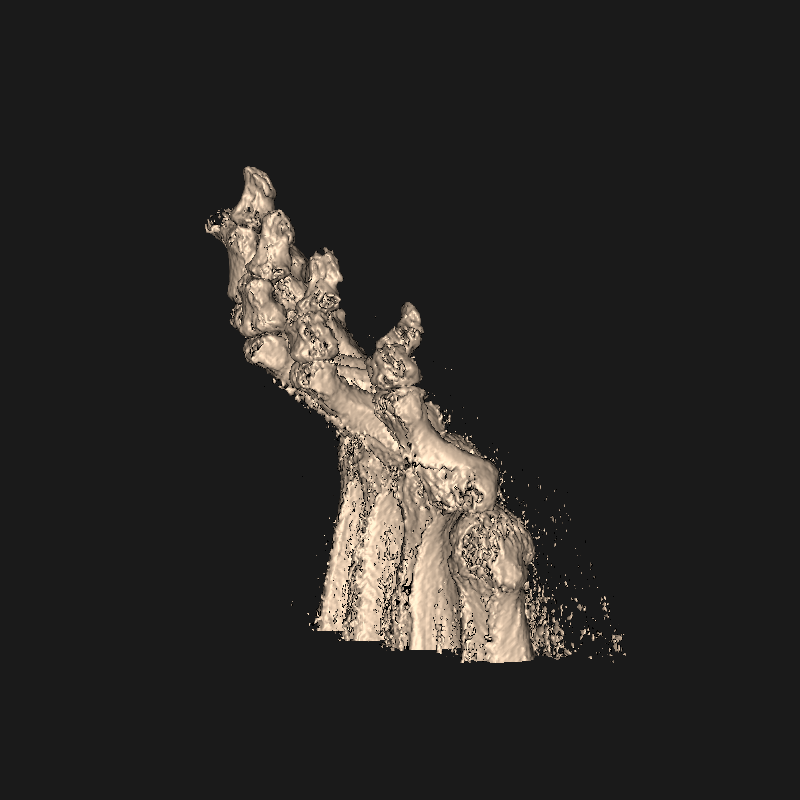

You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.

Your job is to compare the current render with the target view description and
choose exactly one next camera action.

Use comparative hypothesis reasoning rather than committing to the first plausible
view interpretation. Generate a small set of candidate current views and compare
them against the visible evidence. For camera movement, do NOT shortlist candidates:
you must explicitly evaluate every action in the allowed action list before selecting
the single best next action.

Rules:
- Do not map target words like “top,” “up,” “left,” or “right” directly to camera actions, because target directions may be anatomical or object-relative while camera actions are camera-relative.- You are NOT allowed to invent raw camera coordinates.
- You are NOT allowed to output arbitrary angles.
- You are NOT allowed to generate VTK code.
- You MUST choose exactly one final action from the allowed action list below.
- View c

In [3]:
display(Image("../output/screenshots/latest.png"))
print(open("../output/llm_prompt.txt").read())

## Ask ChatGPT

Two ways to use this:

- **Quick loop** (below): auto-generates the prompt from the current camera state and applies whatever action comes back. Good for just running the loop.
- **Prompt experimentation** (further down): lets you edit the prompt text yourself before sending it, and inspect the reply before deciding whether to apply it. Good for testing prompt/reasoning changes.

In [4]:
# session.ask_chatgpt_and_process()

# display(Image("../output/screenshots/latest.png"))
# print(open("../output/llm_prompt.txt").read())

## Run Multiple Iterations

Runs the quick loop repeatedly instead of re-running the cell above by hand. Stops early if `STOP` comes back.

[image_view_matcher] Loaded 18 cached reference embeddings from ../reference_views_relative/image_embeddings.pkl
[text_view_matcher] Loaded 18 cached reference text embeddings from ../reference_views_relative/text_embeddings.pkl
Injecting 18 reference images+descriptions every iteration: ['view_000', 'view_001', 'view_002', 'view_003', 'view_004', 'view_005', 'view_006', 'view_007', 'view_008', 'view_009', 'view_010', 'view_011', 'view_012', 'view_013', 'view_014', 'view_015', 'view_016', 'view_017']
=== Iteration 1/20 ===
Visual diagnosis:
The current screenshot shows a complete foot skeleton viewed from an oblique angle. The structure is oriented with elongated metatarsal bones running roughly horizontally across the lower-center portion of the frame. Above these, a complex cluster of tarsal bones is visible in the upper portion, and individual toe phalanges extend from the right side. The bones appear three-dimensional with visible depth and foreshortening. The overall silhouette pr

/Users/chulu/Documents/llm-vis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[image_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[text_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...
Top-3 similar image views (BEFORE this iteration's camera action):
    1. view_003             similarity=1.0000
    2. view_004             similarity=0.9355
    3. view_013             similarity=0.9334
Top-3 similar description views:
    1. view_007             similarity=0.8484
    2. view_003             similarity=0.8325
    3. view_011             similarity=0.8298
Extracted action: ELEVATION_UP_COARSE
Step 1: ELEVATION_UP_COARSE applied.


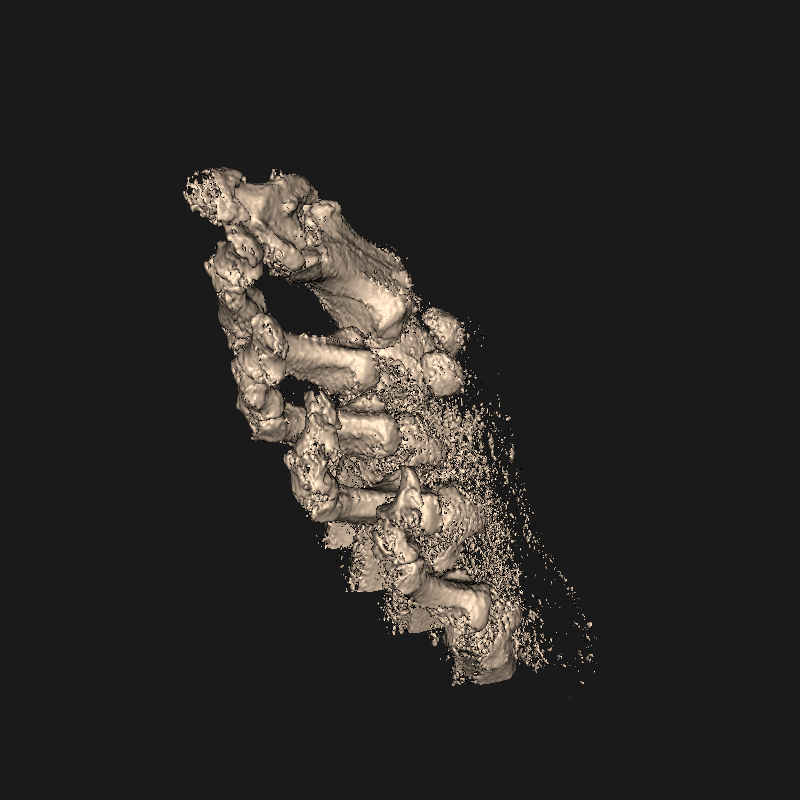

=== Iteration 2/20 ===
Visual diagnosis:
The current screenshot shows a foot skeleton viewed from an oblique angle. Five elongated metatarsal bones are prominently visible in the lower/center portion, arranged roughly parallel and extending from left to right across the frame. Above these shaft bones, a complex cluster of irregular tarsal bones occupies the upper portion. Small phalangeal toe bones are visible in the upper right area. The structure curves gently through space, with some bones appearing in the foreground and others receding. The overall orientation shows the foot angled with toe elements toward the upper right and the heel/ankle region toward the upper left/center. The view is neither a pure top-down perspective nor a pure side view, but rather an intermediate oblique angle.

Action-by-action evaluation:

action: AZIMUTH_LEFT_COARSE
  effect: Orbits camera 45 degrees counterclockwise around the foot structure
  relation_to_target: Would rotate the viewpoint horizontally

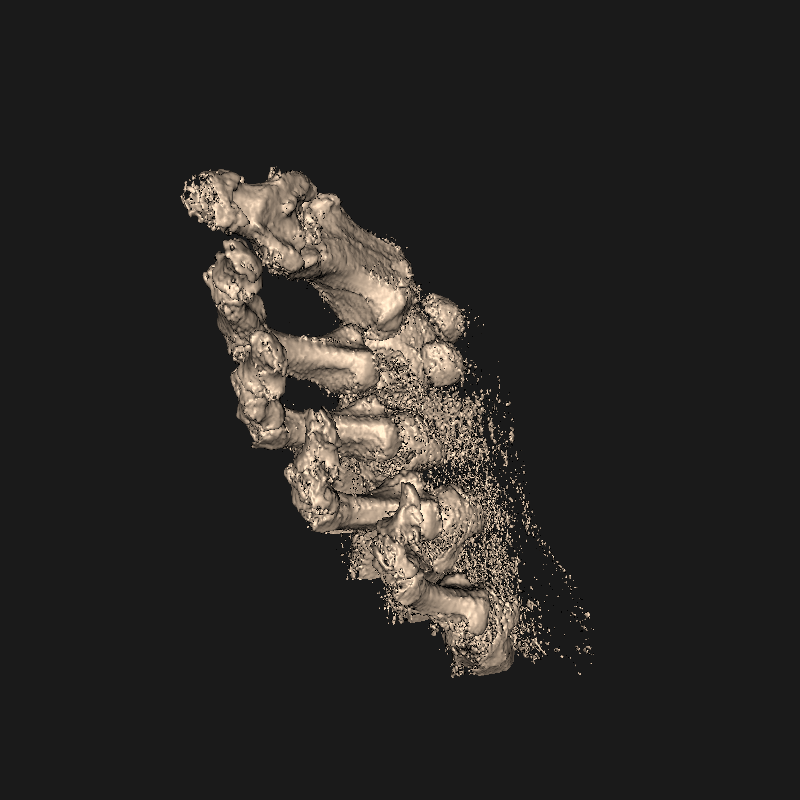

=== Iteration 3/20 ===
Visual diagnosis:
The current screenshot shows a complex view of foot bones rendered in beige/tan against a black background. The structure is oriented with elongated metatarsal shafts visible in the lower-center portion, running roughly parallel to each other. Above these shafts, in the upper portion, is a dense cluster of irregular tarsal bones with complex three-dimensional surfaces and articulations. To the right side of the upper region, individual toe phalanges are visible with their characteristic segmented appearance. The entire structure exhibits a natural arch curvature running through its length. The bones show detailed surface texture including roughness, foramina, and trabecular structure. The view presents significant foreshortening with depth variation from foreground to background. Some fragmentary or point-cloud rendering artifacts are visible, particularly around edges.

Action-by-action evaluation:

action: AZIMUTH_LEFT_COARSE
  effect: Orbits 

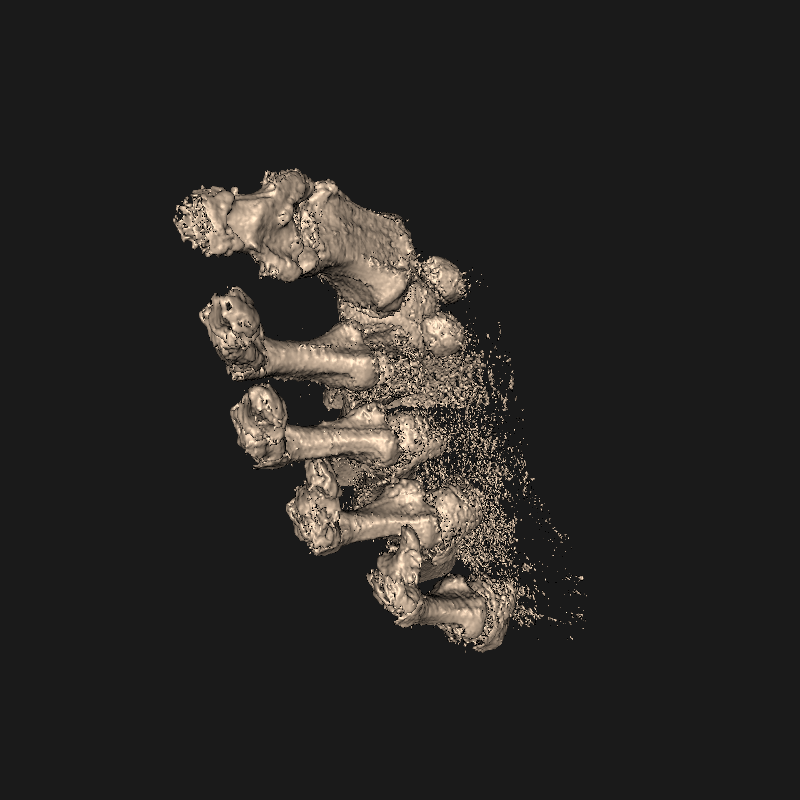

=== Iteration 4/20 ===
Visual diagnosis:
The current screenshot shows foot bones viewed from an oblique angle, with five toe rays extending horizontally across the upper portion of the frame. The elongated metatarsal bones run roughly parallel in the center and lower portion, appearing as vertical shafts with textured surfaces. The tarsal/hindfoot bones are clustered in the upper region as an irregular mass of rounded and angular bones. The overall orientation shows the toes pointing upward in the frame, with the ankle region at the top. The view captures the plantar (bottom) and medial (inner) aspects of the foot with significant three-dimensional depth and foreshortening.

Action-by-action evaluation:

action: AZIMUTH_LEFT_COARSE
  effect: Orbits the camera 45 degrees left around the foot structure
  relation_to_target: Would rotate the viewpoint horizontally, potentially changing which side of the foot is visible but not addressing the need for a superior (top-down) view
  predicted

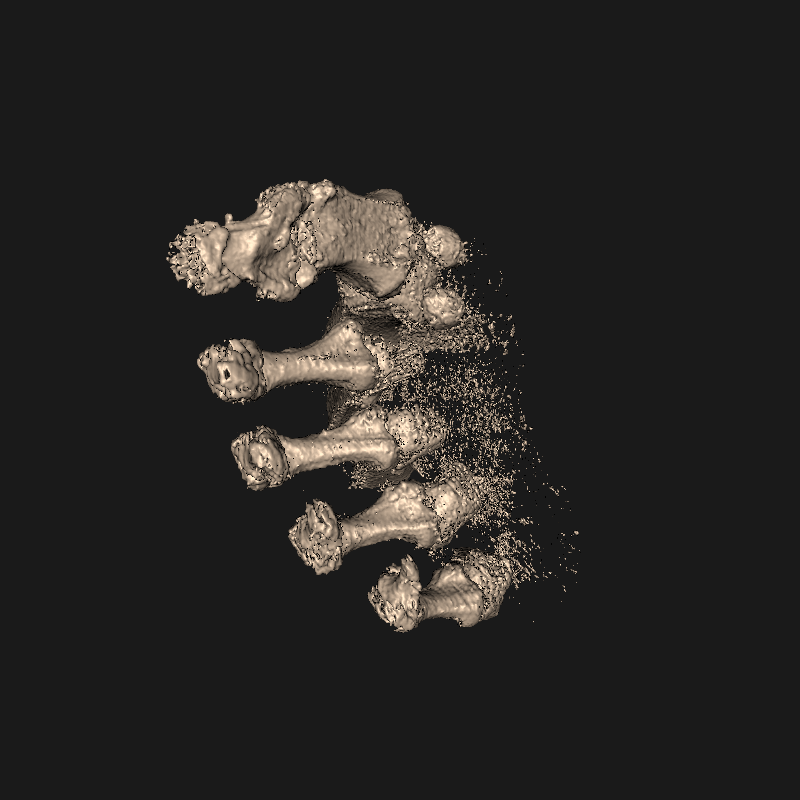

=== Iteration 5/20 ===
Visual diagnosis:
The current screenshot shows foot bones viewed from an oblique angle that emphasizes the superior-lateral-posterior aspect. Five metatarsal shafts are visible in the center-lower portion of the frame, running roughly horizontally across the image. Above these shafts, a complex cluster of tarsal bones is visible in the upper portion, showing irregular, rounded surfaces with considerable three-dimensional depth. To the right side, small phalangeal segments of toes are visible. The overall structure is tilted so that what should be the plantar (bottom) surface faces somewhat toward the viewer, while the dorsal (top) surface faces away. The toes appear in the upper-right, and the heel/ankle region is on the left. The view is NOT a true top-down view; there is significant oblique rotation that shows lateral and posterior aspects of the bones.

Action-by-action evaluation:

action: AZIMUTH_LEFT_COARSE
  effect: Orbits camera 45 degrees counterclockwis

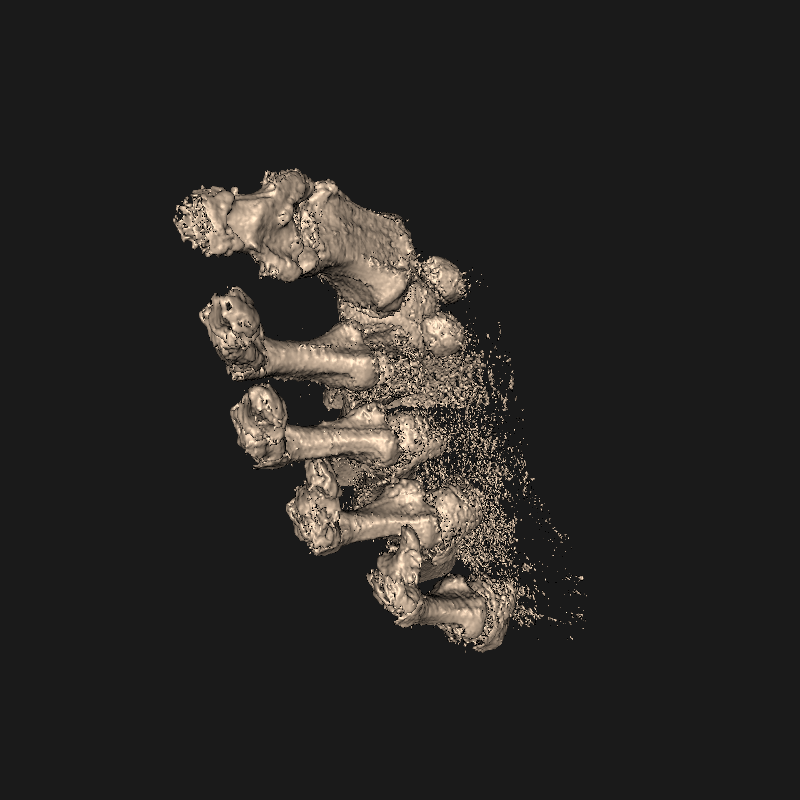

=== Iteration 6/20 ===
Visual diagnosis:
The current screenshot shows a foot skeleton viewed from what appears to be an oblique angle, rotated to show both superior and slightly medial/lateral aspects. Five elongated metatarsal bones are visible as parallel tubular structures running roughly horizontally across the lower-center of the frame. Above these metatarsals, a cluster of irregular tarsal bones occupies the upper portion, showing complex three-dimensional arrangement. Individual toe bones (phalanges) extend from the metatarsals in the upper-right area, with segmentation visible between individual phalangeal elements. The overall structure displays a gentle arch and the bones show detailed surface texture. The view is neither a pure top-down plantar/dorsal view nor a clear side view, but rather an intermediate oblique perspective that shows depth and three-dimensional relationships between bones.

Action-by-action evaluation:

action: AZIMUTH_LEFT_COARSE
  effect: Orbits camera 4

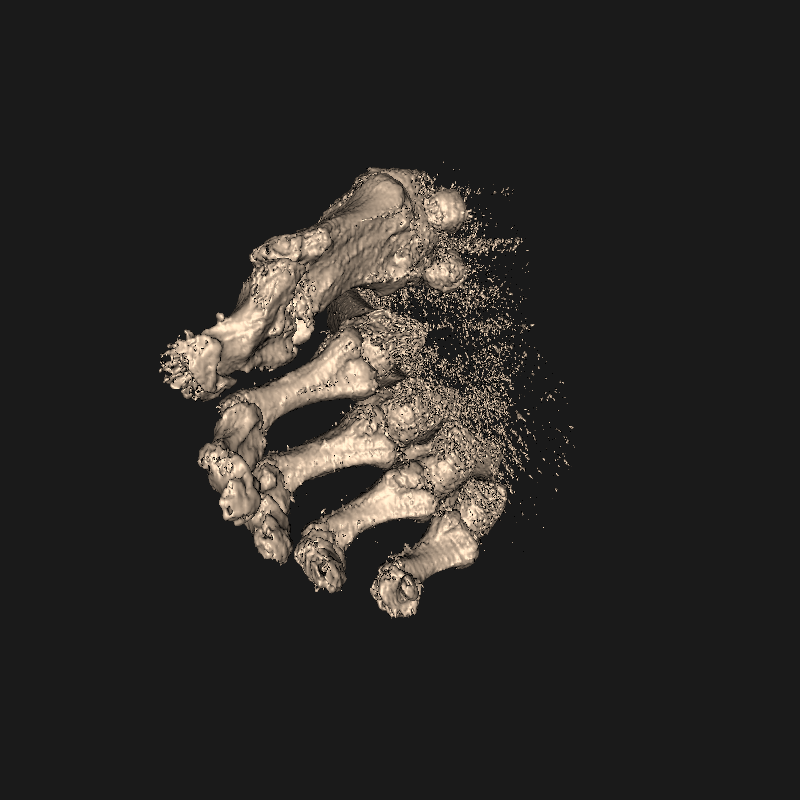

=== Iteration 7/20 ===


KeyboardInterrupt: 

In [5]:
import json
from camera_reasoning.spatial_knowledge import extract_diagnosis_sections
from camera_reasoning.image_view_matcher import ImageViewMatcher
from camera_reasoning.text_view_matcher import TextViewMatcher
from camera_reasoning.frozen_reference_alignment import verify_observation_against_embeddings

# Built once, reused every iteration below — only the query (current screenshot /
# current observation text) gets re-encoded per iteration, not the reference database.
# Cache paths are scoped under reference_views_relative/ (not the shared top-level
# reference_embeddings.pkl / reference_text_embeddings.pkl) so switching back to
# ../reference_views later can't silently load a stale cache built from this bank.
image_matcher = ImageViewMatcher(reference_dir="../reference_views_relative", cache_path="../reference_views_relative/image_embeddings.pkl")
image_matcher.build_index()
text_matcher = TextViewMatcher(descriptions_path="../reference_views_relative/view_descriptions.json", cache_path="../reference_views_relative/text_embeddings.pkl")
text_matcher.build_index()

# reference_items: injected into every ask_chatgpt() call below so the model sees
# each reference image immediately followed by its own description (image,
# description, image, description, ...) rather than images and text separately.
# Built once here (the graph bank doesn't change mid-loop), reused every iteration.
_nodes = json.loads(open("../reference_views_relative/camera_nodes.json").read())
_descriptions = {d["node_id"]: d["description"] for d in json.loads(open("../reference_views_relative/view_descriptions.json").read())}
reference_items = [
    (n["node_id"], "../" + n["image_path"], _descriptions[n["node_id"]])
    for n in _nodes
    if n["node_id"] in _descriptions
]
print(f"Injecting {len(reference_items)} reference images+descriptions every iteration: {[label for label, _, _ in reference_items]}")

num_iterations = 20

for i in range(num_iterations):
    print(f"=== Iteration {i + 1}/{num_iterations} ===", flush=True)

    # Capture the screenshot path BEFORE applying any action this iteration —
    # process_chatgpt_response() below re-renders and overwrites latest.png, so
    # verification must run first, against the exact same image the model saw
    # (and described in its "Visual observation"), not the post-rotation result.
    current_image_path = "../output/screenshots/latest.png"

    response = session.ask_chatgpt(reference_items=reference_items)
    print(response, flush=True)

    observation_text = extract_diagnosis_sections(response).get("visual_observation")
    if observation_text:
        verification = verify_observation_against_embeddings(
            current_image_path, observation_text, image_matcher, text_matcher, top_k=5
        )
        print("Top-3 similar image views (BEFORE this iteration's camera action):", flush=True)
        for m in verification["image_top_k"][:3]:
            print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
        print("Top-3 similar description views:", flush=True)
        for m in verification["text_top_k"][:3]:
            print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
    else:
        print("No 'Visual observation' section found in response; skipping verification.", flush=True)

    # NOW apply the action — this re-renders and overwrites latest.png with the new view.
    action = session.process_chatgpt_response(response)

    display(Image("../output/screenshots/latest.png"))
    if action == "STOP":
        break

## Experiment with a Custom Prompt

1. Start from the auto-generated prompt (or write your own from scratch).
2. Edit `custom_prompt` however you like — reword the rules, add few-shot examples, change the target description, etc.
3. Run the next cell to send it and see the raw reply, without applying anything yet.
4. If you're happy with the result, run the final cell to apply the returned action.

In [ ]:
# Start from the auto-generated prompt, then edit freely.
custom_prompt = session.write_llm_prompt()
print(custom_prompt)

In [ ]:
# Edit custom_prompt above (or reassign it directly here), then send it without applying the result.
response = session.ask_chatgpt(prompt=custom_prompt)
print(response)

In [ ]:
# Happy with the response? Apply it.
session.process_chatgpt_response(response)

display(Image("../output/screenshots/latest.png"))

## Frozen-Reference-Embedding Alignment (Experimental)

An alternative to the text-based loop above. Instead of reasoning from scratch every
iteration, it:
1. Picks the single most visually similar reference view **once**, via image
   embeddings (`reference_views/`), and freezes it as the alignment target.
2. Every iteration: the LLM describes the current screenshot and compares it against
   that same frozen target (never re-picks a new target), then chooses a camera action.
3. Also cross-checks the LLM's own description against the reference database via
   both image embeddings and text embeddings — printing the top-3 matches (with
   scores) from each, every iteration, so you can spot when the LLM's words disagree
   with what the embeddings say.

Requires `reference_views/` + `reference_views/view_descriptions.json` to already
exist (see `examples/generate_reference_views.py` and
`camera_reasoning/view_description_generator.py` if you haven't generated them yet).

In [ ]:
from camera_reasoning.frozen_reference_alignment import run_camera_reasoning_pipeline

result = run_camera_reasoning_pipeline(
    session,
    num_iterations=5,
    use_frozen_reference_alignment=True,
    references_dir="../reference_views",
    dry_run=False,  # set True to freeze the target + analyze/reason once WITHOUT moving the camera
)

display(Image("../output/screenshots/latest.png"))
print("\nFrozen target view:", result["alignment_target_reference"]["view_name"])
print("Applied actions:", result["applied_actions"])

---
## Utilities

In [ ]:
# Manually apply an action without calling the OpenAI API
# session.process_chatgpt_response("Next action:\nAZIMUTH_RIGHT_MEDIUM")

# Or paste a ChatGPT reply you already have (e.g. from the web UI) and process it directly:
# chatgpt_response = """Next action:\nAZIMUTH_RIGHT_MEDIUM"""
# session.process_chatgpt_response(chatgpt_response)

In [ ]:
# Hard-reset the camera (destroys manual alignment)
# session.reset_camera()
# session.render_and_save()
# display(Image("../output/screenshots/latest.png"))

In [ ]:
# Restore camera from a saved state
# session.load_camera_state("../output/camera_states/step_003_ELEVATION_UP_MEDIUM.json")